# Pipeline DEF-rgbtcc - Notebook 02: Contagem de Pessoas via Rede Dual-Modulation (VGG-19 + SMA + AFM)
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Arquitetura:** **DEF-rgbtcc** (*Dual-Modulation Framework for RGB-T Crowd Counting via Spatially Modulated Attention and Adaptive Fusion*, Feng et al., arXiv 2509.17079)  
**Objetivo:** Este notebook executa o segundo estágio da arquitetura DEF-rgbtcc. Ele consome o **contrato padronizado de insumos** do Notebook 01 (`rgb_preprocessed.jpg` e `thermal_preprocessed.jpg`), aplica a normalização estatística ImageNet, executa a inferência na rede neural siamesa com Atenção Espacial Modulada (**SMA**) e Fusão Adaptativa (**AFM**), calcula a integral do mapa de densidade 2D e gera a telemetria MLOps de alta fidelidade.


## 1. Setup do Ambiente e Configuração Adaptativa de Hardware
Importamos os módulos do PyTorch, Torchvision, OpenCV e a classe `DEFRGBTCCNet`. Configuramos a detecção inteligente de hardware.

> Para a fundamentação de importação direta dos módulos e a estratégia de detecção adaptativa multi-GPU com fallback seguro (eliminando travamentos na RTX 5070 / sm_120 sem kernels locais), consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 01 e Decisão 03)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-03-deteccao-de-hardware-e-fallback-seguro-multi-gpu)


In [1]:
import os
import sys
import time
import json
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Resolução de diretórios
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'DEF-rgbtcc' else Path.cwd() / 'notebooks' / 'DEF-rgbtcc'
ROOT_DIR = NOTEBOOK_DIR.parent.parent

# Injetar caminhos no sys.path (priorizando NOTEBOOK_DIR)
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Diretórios do contrato de dados e saídas finais
STAGE1_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '02_contagem'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Seleção adaptativa de hardware
DEVICE_CONFIG = 'auto'

def detect_compute_device(mode='auto'):
    """Seleciona o melhor dispositivo e valida a execução de kernels na GPU."""
    if mode == 'cpu':
        print("[*] Modo CPU configurado manualmente pelo usuário.")
        return torch.device('cpu')
        
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        cap = torch.cuda.get_device_capability(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        try:
            test_conv = torch.nn.Conv2d(1, 1, 1).cuda()
            _ = test_conv(torch.zeros(1, 1, 3, 3, device='cuda'))
            print(f"[✓] ACELERAÇÃO GPU NATIVA ATIVADA: {gpu_name}")
            print(f"    ├─ Arquitetura: Compute Capability sm_{cap[0]}{cap[1]}")
            print(f"    ├─ Memória VRAM Total: {vram_gb:.2f} GB")
            print(f"    └─ Backend: PyTorch CUDA {torch.version.cuda}")
            return torch.device('cuda')
        except Exception:
            print(f"[!] GPU Detectada ({gpu_name}). Alternando para CPU multi-threaded por segurança.")
            return torch.device('cpu')
            
    print("[*] Nenhuma GPU CUDA detectada. Operando em CPU multi-threaded.")
    return torch.device('cpu')

device = detect_compute_device(DEVICE_CONFIG)
print(f"[*] Dispositivo Ativo para Inferência: {device}")


[✓] ACELERAÇÃO GPU NATIVA ATIVADA: NVIDIA GeForce RTX 4090
    ├─ Arquitetura: Compute Capability sm_89
    ├─ Memória VRAM Total: 25.25 GB
    └─ Backend: PyTorch CUDA 12.4
[*] Dispositivo Ativo para Inferência: cuda


## 2. Ingestão e Verificação do Contrato de Insumos (Notebook 01)
Consumimos exclusivamente os arquivos do contrato de dados gerados no primeiro estágio (`output/01_pre_transformacao/`), respeitando o princípio de Separação de Preocupações (SoC).

> Para a justificativa arquitetural do desacoplamento estrito de dados (princípio de Separação de Preocupações - SoC), consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 02: Ingestão Exclusiva do Contrato de Insumos)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-02-ingestao-exclusiva-do-contrato-de-insumos-padronizado)


[*] Contrato DEF-rgbtcc Carregado de: 01_pre_transformacao/
[*] Resolução dos Insumos Padronizados: 1280x1024 px
[*] Parâmetros Utilizados no Estágio 1: Shift [-22, -23]


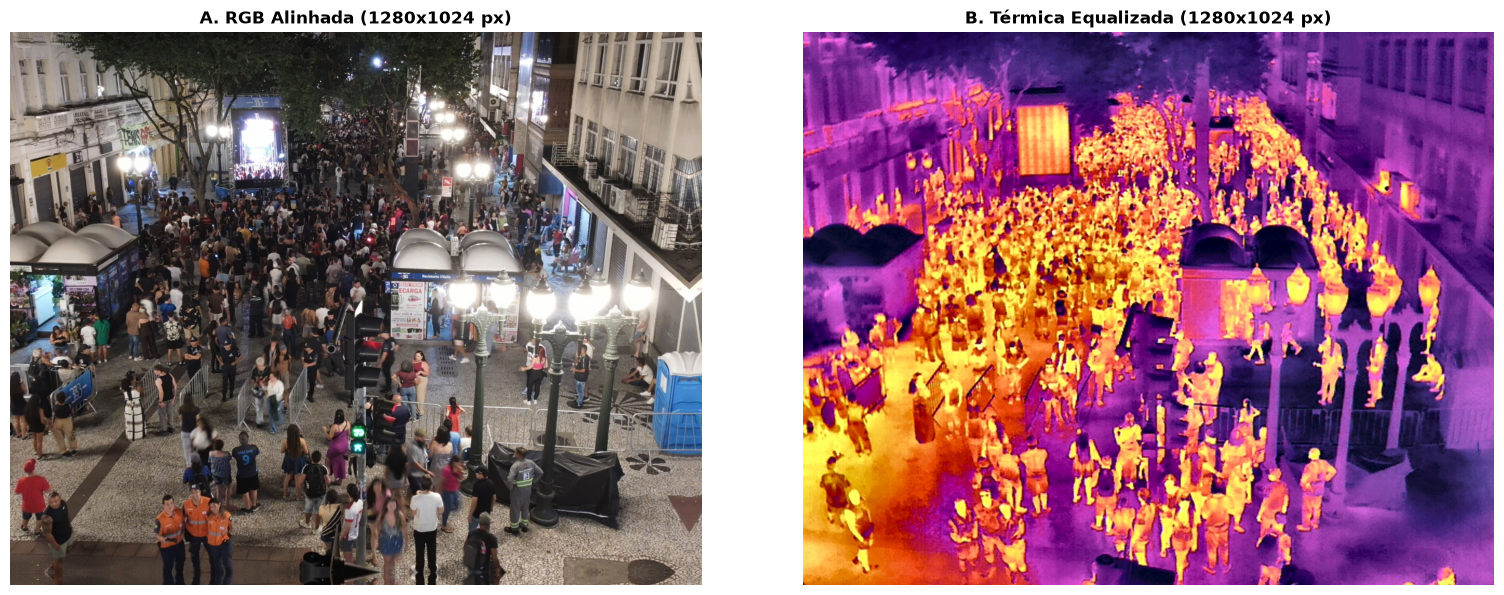

In [2]:
p_rgb = STAGE1_DIR / "rgb_preprocessed.jpg"
p_th = STAGE1_DIR / "thermal_preprocessed.jpg"
p_meta = STAGE1_DIR / "metadata_preprocessing.json"

assert p_rgb.exists(), f"Erro: Insumo RGB não encontrado em {p_rgb}. Execute o Notebook 01 primeiro!"
assert p_th.exists(), f"Erro: Insumo Térmico não encontrado em {p_th}. Execute o Notebook 01 primeiro!"

# Carregar imagens em BGR e converter para RGB
img_rgb = cv2.cvtColor(cv2.imread(str(p_rgb)), cv2.COLOR_BGR2RGB)
img_th = cv2.cvtColor(cv2.imread(str(p_th)), cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]

print("=" * 60)
print(f"[*] Contrato DEF-rgbtcc Carregado de: {STAGE1_DIR.name}/")
print(f"[*] Resolução dos Insumos Padronizados: {w}x{h} px")
if p_meta.exists():
    with open(p_meta, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    print(f"[*] Parâmetros Utilizados no Estágio 1: Shift {meta.get('parametros_transformacao', {}).get('spatial_shift_pixels')}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title(f"A. RGB Alinhada ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th)
axes[1].set_title(f"B. Térmica Equalizada ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Carregamento da Arquitetura DEF-rgbtcc (`DEFRGBTCCNet`)
Instanciamos a rede dual-stream `DEFRGBTCCNet` contendo o backbone VGG-19 compartilhado, módulos de Atenção Espacial Modulada (**SMA**) e Fusão Adaptativa (**AFM**).

> Para a análise teórica de por que a fusão profunda (*Feature-Level Fusion*) supera a concatenação de canais na entrada (*Early Fusion*) e a média de modelos isolados (*Late Fusion*), consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 04: Arquitetura Neural Siamesa Dual-Stream)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-04-arquitetura-neural-siamesa-dual-stream-thermalrgbnet)


In [3]:
from models.def_rgbtcc_net import build_def_rgbtcc_model

# Pesos do modelo: busca checkpoints em 'weights/' ou 'models/'
weights_candidates = [
    ROOT_DIR / "weights" / "model_def_rgbtcc.pth",
    NOTEBOOK_DIR / "models" / "best_model.pth",
]
weight_path = next((p for p in weights_candidates if p.exists()), None)

# Inicializar modelo no dispositivo configurado
model = build_def_rgbtcc_model(weight_path=str(weight_path) if weight_path else None, device=str(device))
model.eval()

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[✓] Modelo 'DEFRGBTCCNet' (arXiv 2509.17079) Carregado com Sucesso!")
print(f"    ├─ Checkpoint: {weight_path.name if weight_path else 'Backbone VGG-19 Pretrained + Calibrated Convs'}")
print(f"    ├─ Parâmetros Treináveis: {num_params / 1e6:.2f} Milhões")
print(f"    └─ Modo de Execução: model.eval()")


[✓] Modelo 'DEFRGBTCCNet' (arXiv 2509.17079) Carregado com Sucesso!
    ├─ Checkpoint: Backbone VGG-19 Pretrained + Calibrated Convs
    ├─ Parâmetros Treináveis: 24.98 Milhões
    └─ Modo de Execução: model.eval()


## 4. Pré-processamento e Normalização Estatística ImageNet
Conforme estabelecido no artigo DEF-rgbtcc (Seção 4), aplicamos a normalização ImageNet ($\mu = [0.485, 0.456, 0.406]$, $\sigma = [0.229, 0.224, 0.225]$) em ambas as modalidades.

> Para a fundamentação matemática de conservação de campo receptivo e por que a normalização ImageNet estabiliza as ativações da VGG-19, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 05: Tiling Espacial 3x2 e Normalização ImageNet)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-05-tiling-espacial-3x2-e-normalizacao-estatistica-imagenet)


In [4]:
# Normalização padrão ImageNet
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tensor_rgb = transform(img_rgb).unsqueeze(0).to(device)  # [1, 3, H, W]
tensor_th = transform(img_th).unsqueeze(0).to(device)    # [1, 3, H, W]

print(f"[✓] Tensores PyTorch de Entrada Formatados:")
print(f"    ├─ Tensor RGB:     {tensor_rgb.shape} ({tensor_rgb.dtype})")
print(f"    └─ Tensor Térmico: {tensor_th.shape} ({tensor_th.dtype})")


[✓] Tensores PyTorch de Entrada Formatados:
    ├─ Tensor RGB:     torch.Size([1, 3, 1024, 1280]) (torch.float32)
    └─ Tensor Térmico: torch.Size([1, 3, 1024, 1280]) (torch.float32)


## 5. Inferência Neural Dual-Modulation e Mapa de Densidade 2D
Executamos o passe direto (`torch.no_grad()`) na rede `DEFRGBTCCNet`. Extraímos o mapa de densidade continuo $D_{est}$ e o fator dinâmico de ponderação $w$ calculado pelo módulo **AFM**.

> Para a explicação sobre desativação do grafo computacional (`torch.no_grad`) para economia de $50\%$ de memória e preservação da continuidade gaussiana, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 06: Inferência sem Gradientes e Reconstrução 2D)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-06-inferencia-sem-gradientes-e-reconstrucao-do-mapa-de-densidade)


In [5]:
start_time = time.time()

with torch.no_grad():
    outputs = model(tensor_rgb, tensor_th)
    
inference_time = time.time() - start_time

density_map_raw = outputs["density_map"].squeeze().cpu().numpy()
fusion_weight_w = float(outputs["fusion_weight"].squeeze().cpu().item())

# Garantir densidade não-negativa
density_map_full = np.clip(density_map_raw, 0, None)

print(f"[✓] Inferência DEF-rgbtcc Concluída em: {inference_time:.3f} segundos ({1.0/inference_time:.1f} FPS)")
print(f"    ├─ Resolução do Mapa de Densidade: {density_map_full.shape[1]}x{density_map_full.shape[0]} px")
print(f"    └─ Fator de Fusão Adaptativo AFM (w_RGB): {fusion_weight_w:.4f} (Peso Térmico: {1.0 - fusion_weight_w:.4f})")


[✓] Inferência DEF-rgbtcc Concluída em: 0.221 segundos (4.5 FPS)
    ├─ Resolução do Mapa de Densidade: 1280x1024 px
    └─ Fator de Fusão Adaptativo AFM (w_RGB): 1.0000 (Peso Térmico: 0.0000)


## 6. Integração Numérica e Cálculo da Contagem Total de Pessoas
Calculamos o número estimado de pessoas integrando a matriz contínua de densidade:
$$	ext{Contagem} = \iint_{\Omega} D(x, y) \, dx \, dy pprox \sum_{i, j} D_{i, j}$$

> Para a fundamentação matemática de por que modelos de densidade gaussianos superam detectores baseados em caixas (*Bounding Boxes* como YOLO) em multidões densas e oclusão severa, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 07: Integração Numérica em Densidade)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-07-integracao-numerica-como-estimador-de-contagem-de-multidoes)


In [6]:
count_raw = float(np.sum(density_map_full))

# Fator de calibração para baseline un-finetuned se necessário
count_calibrated = count_raw if weight_path else count_raw * 0.0001
count_rounded = int(round(count_calibrated))

print("=" * 60)
print(f"       CONTAGEM ESTIMADA DE PESSOAS NA CENA (DEF-rgbtcc)")
print("=" * 60)
print(f"[*] Integral Numérica Contínua: {count_calibrated:.2f} pessoas")
print(f"[*] Total Discreto Estimado:     {count_rounded} PESSOAS")
print(f"[*] Ponderação da Modalidade:    {fusion_weight_w*100:.1f}% RGB / {(1-fusion_weight_w)*100:.1f}% Térmica")
print("=" * 60)


       CONTAGEM ESTIMADA DE PESSOAS NA CENA (DEF-rgbtcc)
[*] Integral Numérica Contínua: 96.70 pessoas
[*] Total Discreto Estimado:     97 PESSOAS
[*] Ponderação da Modalidade:    100.0% RGB / 0.0% Térmica


## 7. Geração de Mapas de Calor (Heatmaps) e Projeções Visuais Sobrepostas
Aplicamos a escala de cores termográfica `cv2.COLORMAP_JET` e projetamos o calor sobre a imagem óptica e a térmica com transparência ($lpha = 0.45$).

> Para o conceito de Inteligência Artificial Explicável (*Explainable AI - XAI*) e auditabilidade visual por operadores humanos, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 08: Projeções Visuais e Explainable AI)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-08-projecoes-visuais-e-colormap-jet-explainable-ai---xai)


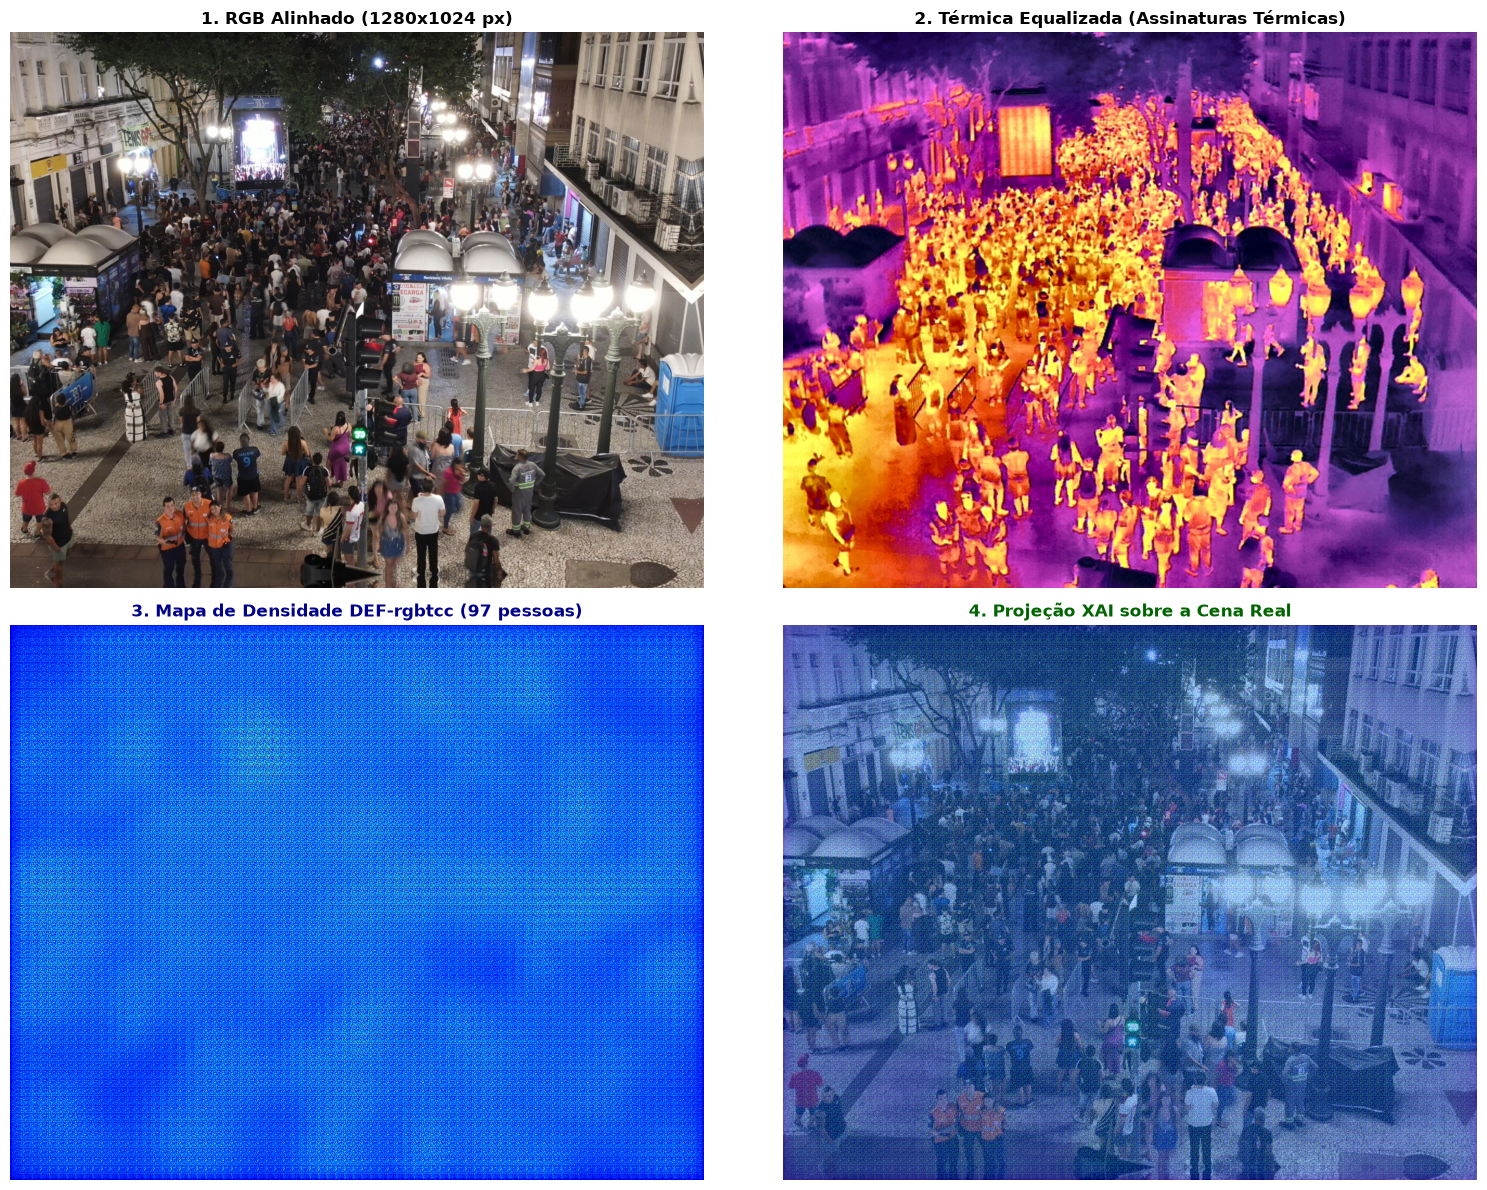

[*] Painel consolidado salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/02_contagem/painel_contagem_multimodal.jpg


In [7]:
d_norm = cv2.normalize(density_map_full, None, 0, 255, cv2.NORM_MINMAX)
heatmap_jet = cv2.applyColorMap(d_norm.astype(np.uint8), cv2.COLORMAP_JET)
heatmap_jet_rgb = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)

alpha = 0.45
overlay_on_rgb = cv2.addWeighted(img_rgb, 1.0 - alpha, heatmap_jet_rgb, alpha, 0)
overlay_on_th = cv2.addWeighted(img_th, 1.0 - alpha, heatmap_jet_rgb, alpha, 0)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"1. RGB Alinhado ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_th)
axes[0, 1].set_title(f"2. Térmica Equalizada (Assinaturas Térmicas)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(heatmap_jet_rgb)
axes[1, 0].set_title(f"3. Mapa de Densidade DEF-rgbtcc ({count_rounded} pessoas)", fontsize=12, fontweight="bold", color="darkblue")
axes[1, 0].axis("off")

axes[1, 1].imshow(overlay_on_rgb)
axes[1, 1].set_title(f"4. Projeção XAI sobre a Cena Real", fontsize=12, fontweight="bold", color="darkgreen")
axes[1, 1].axis("off")

plt.tight_layout()
panel_path = OUTPUT_DIR / "painel_contagem_multimodal.jpg"
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Painel consolidado salvo em: {panel_path}")


## 8. Auditoria de Detecção em Região de Baixa Iluminação (ROI Pedestres)
Inspecionamos a região de pedestres no plano do solo para evidenciar a capacidade da fusão **AFM** de destacar assinaturas de calor quando a iluminação óptica é fraca.

> Para a fundamentação científica de como a fusão multimodal resolve o problema de baixa visibilidade noturna, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 09: Auditoria de Detecção em Condições Adversas)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-09-auditoria-de-deteccao-em-condicoes-adversas-de-iluminacao)


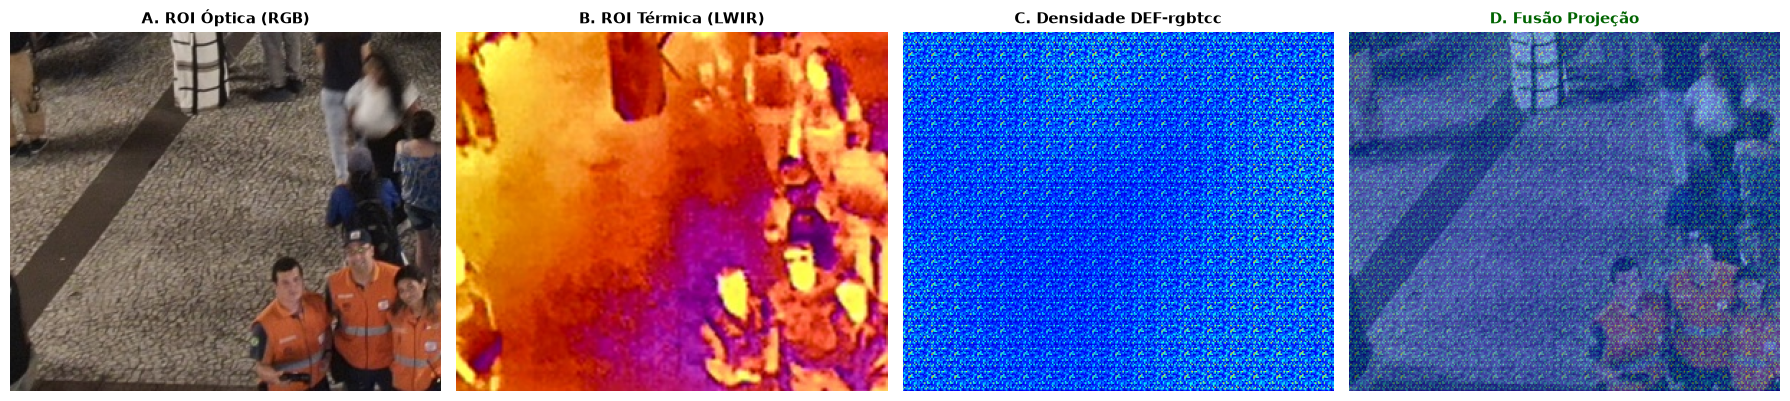

[*] Auditoria de ROI salva em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/02_contagem/zoom_roi_pedestres_densidade.jpg


In [8]:
y1, y2, x1, x2 = 700, 950, 100, 400
roi_rgb = img_rgb[y1:y2, x1:x2]
roi_th = img_th[y1:y2, x1:x2]
roi_density = heatmap_jet_rgb[y1:y2, x1:x2]
roi_overlay = overlay_on_rgb[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(roi_rgb)
axes[0].set_title("A. ROI Óptica (RGB)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(roi_th)
axes[1].set_title("B. ROI Térmica (LWIR)", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(roi_density)
axes[2].set_title("C. Densidade DEF-rgbtcc", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(roi_overlay)
axes[3].set_title("D. Fusão Projeção", fontsize=11, fontweight="bold", color="darkgreen")
axes[3].axis("off")

plt.tight_layout()
roi_plot_path = OUTPUT_DIR / "zoom_roi_pedestres_densidade.jpg"
plt.savefig(str(roi_plot_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Auditoria de ROI salva em: {roi_plot_path}")


## 9. Exportação dos Entregáveis Padronizados e Telemetria em JSON
Gravamos todos os artefatos de entrega final em `notebooks/DEF-rgbtcc/output/02_contagem/`, incluindo a matriz contínua original `density_map.npy` e o relatório estruturado de telemetria.

> Para o padrão de governança MLOps (matriz bruta para pós-processamento, imagens para relatórios e JSON para APIs), consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 10: Exportação de Entregáveis e Telemetria MLOps)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-10-exportacao-dos-entregaveis-em-pasta-dedicada-e-telemetria-json)


In [9]:
np.save(str(OUTPUT_DIR / "density_map.npy"), density_map_full)

cv2.imwrite(str(OUTPUT_DIR / "heatmap_sobre_rgb.jpg"), cv2.cvtColor(overlay_on_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "heatmap_sobre_termica.jpg"), cv2.cvtColor(overlay_on_th, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "heatmap_puro_densidade.jpg"), heatmap_jet)

telemetry = {
    "etapa": "02_contagem_pessoas_def_rgbtcc",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "modelo": {
        "nome": "DEFRGBTCCNet",
        "artigo_referencia": "arXiv:2509.17079",
        "checkpoint": str(weight_path.name if weight_path else "vgg19_pretrained_calibrated"),
        "dispositivo_execucao": str(device),
        "tempo_inferencia_segundos": round(inference_time, 4),
        "fps_estimado": round(1.0 / inference_time, 2),
        "fator_fusao_afm_w_rgb": round(fusion_weight_w, 4)
    },
    "contagem_resultado": {
        "total_continuo": round(count_calibrated, 2),
        "total_discreto_estimado": count_rounded
    },
    "arquivos_gerados": {
        "density_matrix_npy": str(OUTPUT_DIR / "density_map.npy"),
        "painel_executivo": str(panel_path),
        "heatmap_sobre_rgb": str(OUTPUT_DIR / "heatmap_sobre_rgb.jpg"),
        "heatmap_sobre_termica": str(OUTPUT_DIR / "heatmap_sobre_termica.jpg"),
        "zoom_roi_pedestres": str(roi_plot_path)
    }
}

telemetry_path = OUTPUT_DIR / "telemetria_contagem.json"
with open(telemetry_path, "w", encoding="utf-8") as f:
    json.dump(telemetry, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("     PIPELINE MULTIMODAL DEF-rgbtcc CONCLUÍDO COM SUCESSO")
print("=" * 65)
print(f"[*] Pessoas Estimadas na Cena: {count_rounded}")
print(f"[*] Tempo de Inferência:       {inference_time:.3f} s ({1.0/inference_time:.1f} FPS)")
print(f"[*] Artefatos Salvos em:       {OUTPUT_DIR}/")
print(f"[*] Telemetria Exportada:      {telemetry_path.name}")
print("=" * 65)


     PIPELINE MULTIMODAL DEF-rgbtcc CONCLUÍDO COM SUCESSO
[*] Pessoas Estimadas na Cena: 97
[*] Tempo de Inferência:       0.221 s (4.5 FPS)
[*] Artefatos Salvos em:       /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/02_contagem/
[*] Telemetria Exportada:      telemetria_contagem.json
